In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/ImageProcessing/Lab7/'

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
def sum_square_difference(image, template):
  ssd = np.zeros((image.shape[0] - template.shape[0] + 1, image.shape[1] - template.shape[1] + 1))

  for i in range(ssd.shape[0]):
      for j in range(ssd.shape[1]):
          region = image[i:i + template.shape[0], j:j + template.shape[1]]
          ssd[i, j] = np.sum((template - region) ** 2)

  # min_i, min_j = np.unravel_index(np.argmin(ssd), ssd.shape)

  for i in range(ssd.shape[0]):
    for j in range(ssd.shape[1]):
        if ssd[i, j] == np.min(ssd):
            min_i, min_j = i, j

  return ssd, min_i, min_j

1) Template matching in spatial domain using sum square difference

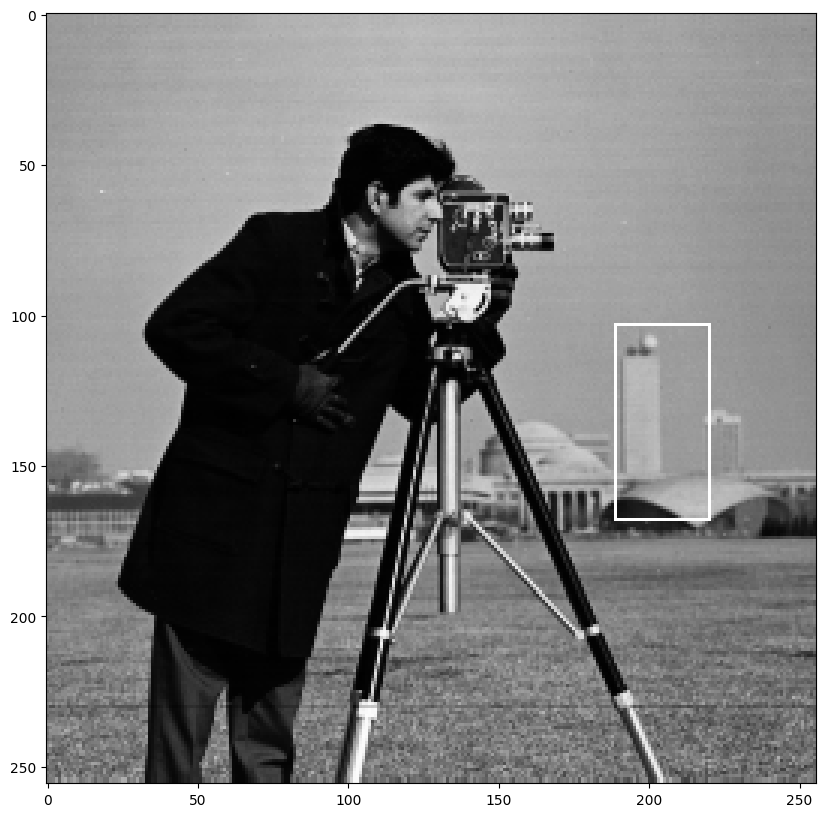

In [116]:
template = cv2.imread(path + 'template.bmp', 0)
image = cv2.imread(path + 'cameraman.tif', 0)

image_with_box = np.copy(image)

ssd, min_i, min_j = sum_square_difference(image, template)

top = min_i
left = min_j
bottom = min_i + template.shape[0] - 1
right = min_j + template.shape[1] - 1

# ขอบบน
image_with_box[top, left:right+1] = 255
# ขอบล่าง
image_with_box[bottom, left:right+1] = 255
# ขอบซ้าย
image_with_box[top:bottom+1, left] = 255
# ขอบขวา
image_with_box[top:bottom+1, right] = 255


plt.figure(figsize=(10,10))

plt.imshow(image_with_box, cmap='gray')
plt.show()

2) Create a panoramic image using sum square difference

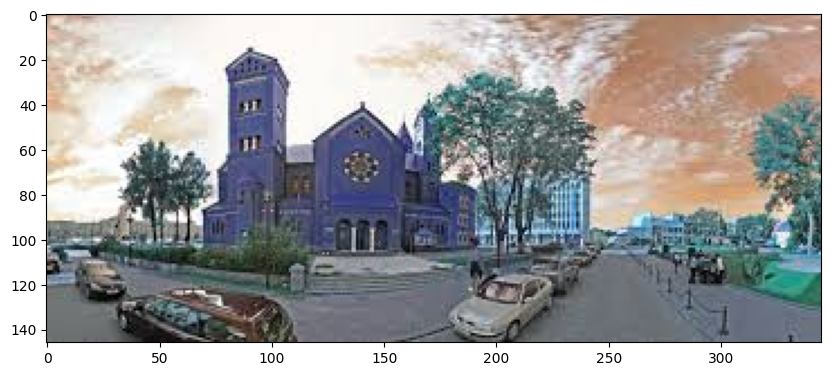

In [118]:
image1 = cv2.imread(path + 'P1.bmp', 1)
image2 = cv2.imread(path + 'P2.bmp', 1)

template = image2[:, 0:1]
ssd, min_i, min_j = sum_square_difference(image1, template)

output_image = np.zeros((image1.shape[0], min_j + image2.shape[1],3), dtype=np.uint8)

# print(np.min(ssd))
# print(min_i,min_j)

# วาง image1 ด้านซ้าย
output_image[0:image1.shape[0], 0:image1.shape[1]] = image1

# วาง image2 โดยเลื่อนตาม offset
output_image[0:image2.shape[0], min_j:min_j + image2.shape[1]] = image2

plt.figure(figsize=(10,10))

plt.imshow(output_image, cmap='gray')

plt.show()